# Cybersecurity Incident Intelligence Dashboard
## Exploratory Data Analysis — EuRepoC Global Dataset of Cyber Incidents (v1.3.2)

**Data source:** EuRepoC (European Repository of Cyber Incidents), [Zenodo record 14965395](https://zenodo.org/records/14965395)
**Files used:** `eurepoc_global_dataset_1_3.csv` (3,414 incidents, 85 columns), `eurepoc_dyadic_dataset_0_1.csv` (4,296 initiator–receiver dyad records)

This notebook covers: data loading, data quality checks, a cleaning pass based on those findings, and the full exploratory analysis (12 visualizations).

**To run:** place `eurepoc_global_dataset_1_3.csv` and `eurepoc_dyadic_dataset_0_1.csv` in the same folder as this notebook.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

DISGUISED_NULLS = ['Not available', 'Unknown', 'Not attributed', '']

## 1. Load Data

In [2]:
df = pd.read_csv('eurepoc_global_dataset_1_3.csv', low_memory=False)
dyad = pd.read_csv('eurepoc_dyadic_dataset_0_1.csv', low_memory=False)

df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce', dayfirst=True)
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce', dayfirst=True)
df['year'] = df['start_date'].dt.year

dyad['start_date'] = pd.to_datetime(dyad['start_date'], errors='coerce', dayfirst=True)
dyad['year'] = dyad['start_date'].dt.year

print("Global dataset:", df.shape)
print("Dyadic dataset:", dyad.shape)
df.head(3)

Global dataset: (3414, 86)
Dyadic dataset: (4296, 58)


,incident_id,name,description,start_date,end_date,inclusion_criterion,inclusion_criterion_subcode,source_disclosure,incident_type,receiver_name,receiver_country,receiver_country_alpha_2_code,receiver_regions,receiver_category,receiver_subcategory,initiator_name,initiator_country,initiator_alpha_2,initiator_category,initiator_subcategory,number_attributions,attribution_id,attribution_date,attribution_type,attribution_basis,...,affected_entities,affected_entities_value,affected_third_countries,affected_third_countries_value,economic_impact,economic_impact_value,economic_impact_currency,state_responsibility_actor,il_breach_indicator,il_breach_indicator_subcode,evidence_for_sanctions_indicator,number_legal_responses,legal_response_date,legal_response_type,legal_response_subtype,legal_response_responding_country,legal_response_responding_actor,attribution_legal_reference,attribution_legal_reference_subcode,response_indicator,casualties,source_url,added_to_db,updated_at,year
0,4163,Russian State-Sponsored Actors Linked to GRU ...,"On 19 December 2024, a cyber attack attributed...",2024-12-19,2024-12-19,Attack conducted by nation state (generic “sta...,Not available;Not available,Incident disclosed by authorities of victim state,Disruption;Hijacking with Misuse,Ministry of Justice (Ukraine),Ukraine,UA,"['EUROPE', 'EASTEU']",State institutions / political system,Government / ministries,Unknown,Russia,RU,State,Not available,1,25486,19.12.2024,"Direct statement in media report (e.g., Reuter...",Attribution by receiver government / state entity,...,1-10,0,1-10,1,NaN,0,euro,Direct (official members of state entities / a...,Armed conflict;Sovereignty,Conduct of hostilities;Not available,Not available,1,2024-12-19,Other legal measures on national level (e.g. l...,Not available,Ukraine,Security Service of Ukraine (SBU),Not available,Not available,Countermeasures under international law justif...,Not available,https://www.t-online.de/nachrichten/ukraine/id...,2024-12-23,2025-02-18,2024.0
1,4161,Unknown threat actors stole Microsoft Azure ac...,Unit 42 researchers uncovered a phishing campa...,2024-06-01,NaT,Attack on critical infrastructure target(s),Not available,Incident disclosed by IT-security company,Data theft;Hijacking with Misuse,Not available;Not available;Not available;Not ...,Germany;Germany;Germany;United Kingdom;United ...,DE;DE;DE;GB;GB;GB;EUROPE;EUROPE;EUROPE,"['EUROPE', 'NATO', 'EU', 'WESTEU'];['EUROPE', ...",Critical infrastructure;Corporate Targets (cor...,Chemicals;Not available;Critical Manufacturing...,Not attributed,Not attributed,Not attributed,Not attributed,Not available,1,25488,Not available,Not available,Not available,...,1-10,0,Not available,0,NaN,0,euro,Not available,Human rights;Sovereignty,Civic / political rights;Not available,Not available,0,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Unfriendly acts/retorsions justified (missing ...,Not available,https://www.bleepingcomputer.com/news/security...,2024-12-20,2025-02-18,2024.0
2,4160,Unspecified US intelligence agencies stole tra...,The Chinese National Internet Emergency Respon...,2023-05-01,NaT,Attack conducted by nation state (generic “sta...,Not available,Incident disclosed by authorities of victim state,Data theft;Hijacking with Misuse,Not available,China,CN,"['ASIA', 'SCS', 'EASIA', 'NEA', 'SCO']",Corporate Targets (corporate targets only code...,Not available,Unknown,United States,US,State,Not available,1,25487,18.12.2024,"Political statement / report (e.g., on governm...",Attribution by receiver government / state entity,...,1-10,2,1-10,1,NaN,0,euro,Direct (official members of state entities / a...,Cyber espionage;Sovereignty,State actors;Not available,Not available,0,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Countermeasures under international law justif...,Not available,https://cyberscoop.com/chinese-cyber-center-us...,2024-12-20,2025-02-18,202

## 2. Data Quality Checks

Key finding: several fields look 0% missing under a plain `.isna()` check, but actually use placeholder text
("Not available" / "Unknown" / "Not attributed") instead of blank cells. We check both.

In [3]:
# 2.1 Uniqueness
print("Duplicate incident_id rows:", df['incident_id'].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum())

Duplicate incident_id rows: 0
Duplicate full rows: 0


In [4]:
# 2.2 Redundant duplicate columns
same_country = (df['initiator_country'].fillna('NA') == df['initiator_country.1'].fillna('NA')).all()
same_category = (df['initiator_category'].fillna('NA') == df['initiator_category.1'].fillna('NA')).all()
print("initiator_country == initiator_country.1 for all rows:", same_country)
print("initiator_category == initiator_category.1 for all rows:", same_category)
print("-> Safe to drop the .1 duplicate columns.")

initiator_country == initiator_country.1 for all rows: True
initiator_category == initiator_category.1 for all rows: True
-> Safe to drop the .1 duplicate columns.


In [5]:
# 2.3 Effective missingness: true NaN + disguised-null placeholders
cols_to_check = ['incident_type','receiver_category','receiver_country','initiator_category','initiator_country',
                  'attribution_type','attribution_basis','state_responsibility_actor','cyber_conflict_issue',
                  'offline_conflict_issue','zero_days','mitre_initial_access','mitre_impact','user_interaction',
                  'economic_impact','il_breach_indicator','evidence_for_sanctions_indicator','response_indicator','casualties']

rows = []
for c in cols_to_check:
    true_na = df[c].isna().mean()*100
    first_tok = df[c].astype(str).str.split(';').str[0]
    disg = first_tok.isin(['Not available','Unknown','Not attributed']).mean()*100
    eff = disg if true_na == 0 else min(100, true_na + disg)
    rows.append((c, round(true_na,1), round(disg,1), round(eff,1)))

missingness = pd.DataFrame(rows, columns=['column','true_NaN_%','disguised_null_%','effective_missing_%'])
missingness = missingness.sort_values('effective_missing_%', ascending=False)
missingness

,column,true_NaN_%,disguised_null_%,effective_missing_%
18,casualties,0.0,100.0,100.0
16,evidence_for_sanctions_indicator,0.0,99.8,99.8
13,user_interaction,4.2,94.8,99.0
14,economic_impact,48.2,49.0,97.2
11,mitre_initial_access,0.0,85.2,85.2
9,offline_conflict_issue,0.0,71.9,71.9
7,state_responsibility_actor,0.0,68.0,68.0
12,mitre_impact,0.0,57.5,57.5
8,cyber_conflict_issue,0.0,53.3,53.3
4,initiator_country,0.0,51.7,51.7


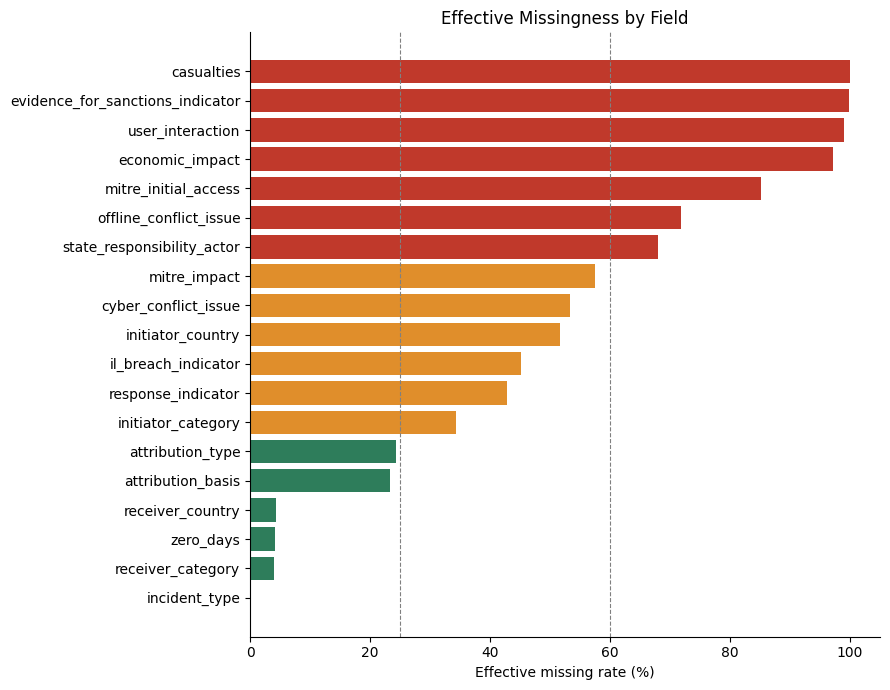

In [6]:
fig, ax = plt.subplots(figsize=(9,7))
sorted_m = missingness.sort_values('effective_missing_%')
colors = ['#c0392b' if v>=60 else '#e08e2b' if v>=25 else '#2e7d5b' for v in sorted_m['effective_missing_%']]
ax.barh(sorted_m['column'], sorted_m['effective_missing_%'], color=colors)
ax.set_xlabel('Effective missing rate (%)')
ax.set_title('Effective Missingness by Field')
ax.axvline(25, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(60, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [7]:
# 2.4 Date validity
print("start_date unparseable:", df['start_date'].isna().sum(), "/", len(df))
print("end_date unparseable:", df['end_date'].isna().sum(), "/", len(df), "(", round(df['end_date'].isna().mean()*100,1), "% )")

bad_order = df[(df['end_date'].notna()) & (df['start_date'].notna()) & (df['end_date'] < df['start_date'])]
print("Rows with end_date before start_date:", len(bad_order))
bad_order[['incident_id','name','start_date','end_date']]

start_date unparseable: 92 / 3414
end_date unparseable: 1873 / 3414 ( 54.9 % )
Rows with end_date before start_date: 2


,incident_id,name,start_date,end_date
50,4101,Unknown threat actors launched a ransomware at...,2024-11-25,2024-01-27
1048,2726,European Shipping companies hit by DDoS attack...,2023-10-19,2023-09-20


In [8]:
# 2.5 Internal duplicate tokens within semicolon multi-value fields
def internal_dup_rate(col):
    s = df[col].dropna().astype(str)
    def has_dup(v):
        parts = [p.strip() for p in v.split(';')]
        return len(parts) != len(set(parts))
    flags = s.apply(has_dup)
    return round(flags.mean()*100, 1)

for col in ['receiver_country','initiator_country','receiver_category','initiator_category','incident_type','receiver_regions']:
    print(f"{col}: {internal_dup_rate(col)}% of rows have a repeated token within the field")

receiver_country: 35.0% of rows have a repeated token within the field
initiator_country: 5.7% of rows have a repeated token within the field
receiver_category: 27.4% of rows have a repeated token within the field
initiator_category: 5.6% of rows have a repeated token within the field
incident_type: 0.7% of rows have a repeated token within the field
receiver_regions: 36.8% of rows have a repeated token within the field


In [9]:
# 2.6 economic_impact (bucket) vs economic_impact_value (numeric) consistency
ct = pd.crosstab(df['economic_impact'].fillna('NaN'),
                  df['economic_impact_value'].apply(lambda x: 'zero/NA' if (pd.isna(x) or x==0) else 'has value'))
ct

economic_impact_value,has value,zero/NA
economic_impact,,
=< 10 Mio,42,15
> 10 Mio - 100 Mio,23,9
> 100 Mio - 1 bn,5,0
NaN,0,1647
Not available,0,1673


**Data quality summary:** structurally clean (no duplicate incidents, dates mostly parse, source URLs present),
but several analytically valuable fields are majority placeholder text. See the standalone Data Quality Report for
the full write-up and recommendations. The cleaning step below applies those recommendations.

## 3. Data Cleaning

In [10]:
def dedup_tokens(cell):
    """Remove repeated tokens within a semicolon-joined cell."""
    if pd.isna(cell):
        return cell
    parts = [p.strip() for p in str(cell).split(';')]
    seen = []
    for p in parts:
        if p not in seen:
            seen.append(p)
    return ';'.join(seen)

df_clean = df.drop(columns=['initiator_country.1', 'initiator_category.1', 'casualties'])

for col in ['receiver_country','initiator_country','receiver_category','initiator_category','incident_type','receiver_regions']:
    df_clean[col] = df_clean[col].apply(dedup_tokens)

df_clean['initiator_cat_clean'] = df_clean['initiator_category'].astype(str).str.split(';').str[0]
df_clean['issue_clean'] = df_clean['cyber_conflict_issue'].astype(str).str.split(';').str[0]
df_clean['not_attributed'] = df_clean['initiator_cat_clean'].isin(['Not attributed','Unknown'])

print("Cleaned shape:", df_clean.shape)
df_clean.head(3)

Cleaned shape: (3414, 86)


,incident_id,name,description,start_date,end_date,inclusion_criterion,inclusion_criterion_subcode,source_disclosure,incident_type,receiver_name,receiver_country,receiver_country_alpha_2_code,receiver_regions,receiver_category,receiver_subcategory,initiator_name,initiator_country,initiator_alpha_2,initiator_category,initiator_subcategory,number_attributions,attribution_id,attribution_date,attribution_type,attribution_basis,...,affected_third_countries,affected_third_countries_value,economic_impact,economic_impact_value,economic_impact_currency,state_responsibility_actor,il_breach_indicator,il_breach_indicator_subcode,evidence_for_sanctions_indicator,number_legal_responses,legal_response_date,legal_response_type,legal_response_subtype,legal_response_responding_country,legal_response_responding_actor,attribution_legal_reference,attribution_legal_reference_subcode,response_indicator,source_url,added_to_db,updated_at,year,initiator_cat_clean,issue_clean,not_attributed
0,4163,Russian State-Sponsored Actors Linked to GRU ...,"On 19 December 2024, a cyber attack attributed...",2024-12-19,2024-12-19,Attack conducted by nation state (generic “sta...,Not available;Not available,Incident disclosed by authorities of victim state,Disruption;Hijacking with Misuse,Ministry of Justice (Ukraine),Ukraine,UA,"['EUROPE', 'EASTEU']",State institutions / political system,Government / ministries,Unknown,Russia,RU,State,Not available,1,25486,19.12.2024,"Direct statement in media report (e.g., Reuter...",Attribution by receiver government / state entity,...,1-10,1,NaN,0,euro,Direct (official members of state entities / a...,Armed conflict;Sovereignty,Conduct of hostilities;Not available,Not available,1,2024-12-19,Other legal measures on national level (e.g. l...,Not available,Ukraine,Security Service of Ukraine (SBU),Not available,Not available,Countermeasures under international law justif...,https://www.t-online.de/nachrichten/ukraine/id...,2024-12-23,2025-02-18,2024.0,State,International power,False
1,4161,Unknown threat actors stole Microsoft Azure ac...,Unit 42 researchers uncovered a phishing campa...,2024-06-01,NaT,Attack on critical infrastructure target(s),Not available,Incident disclosed by IT-security company,Data theft;Hijacking with Misuse,Not available;Not available;Not available;Not ...,Germany;United Kingdom;Europe (region),DE;DE;DE;GB;GB;GB;EUROPE;EUROPE;EUROPE,"['EUROPE', 'NATO', 'EU', 'WESTEU'];['EUROPE', ...",Critical infrastructure;Corporate Targets (cor...,Chemicals;Not available;Critical Manufacturing...,Not attributed,Not attributed,Not attributed,Not attributed,Not available,1,25488,Not available,Not available,Not available,...,Not available,0,NaN,0,euro,Not available,Human rights;Sovereignty,Civic / political rights;Not available,Not available,0,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Unfriendly acts/retorsions justified (missing ...,https://www.bleepingcomputer.com/news/security...,2024-12-20,2025-02-18,2024.0,Not attributed,Unknown,True
2,4160,Unspecified US intelligence agencies stole tra...,The Chinese National Internet Emergency Respon...,2023-05-01,NaT,Attack conducted by nation state (generic “sta...,Not available,Incident disclosed by authorities of victim state,Data theft;Hijacking with Misuse,Not available,China,CN,"['ASIA', 'SCS', 'EASIA', 'NEA', 'SCO']",Corporate Targets (corporate targets only code...,Not available,Unknown,United States,US,State,Not available,1,25487,18.12.2024,"Political statement / report (e.g., on governm...",Attribution by receiver government / state entity,...,1-10,1,NaN,0,euro,Direct (official members of state entities / a...,Cyber espionage;Sovereignty,State actors;Not available,Not available,0,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Countermeasures under international law justif...,https://cyberscoop.com/chinese-cyber-center-us...,2024-12-20,2025-02-18,2023.0,State,Unknown,Fa

## 4. Exploratory Data Analysis

### 4.1 Incidents by Year

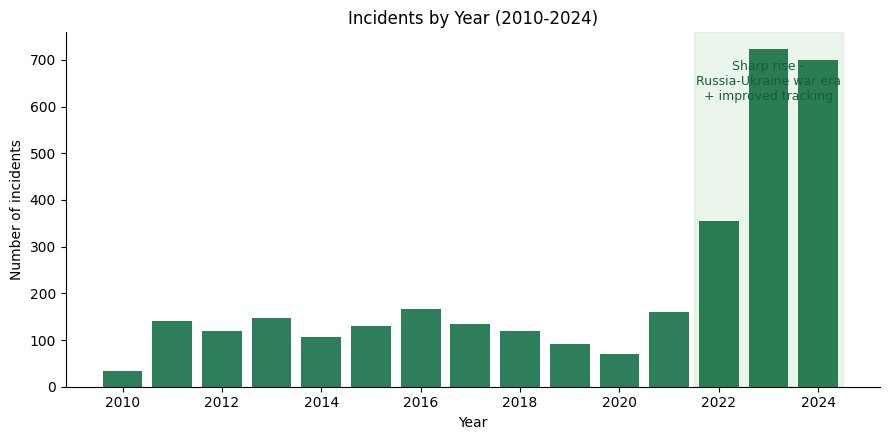

In [11]:
fig, ax = plt.subplots(figsize=(9,4.5))
yearly = df_clean[(df_clean['year']>=2010)&(df_clean['year']<=2024)]['year'].value_counts().sort_index()
ax.bar(yearly.index, yearly.values, color='#2e7d5b')
ax.axvspan(2021.5, 2024.5, color='green', alpha=0.08)
ax.text(2023, yearly.max()*0.85, "Sharp rise -\nRussia-Ukraine war era\n+ improved tracking",
        ha='center', fontsize=9, color='#1a5c3a')
ax.set_title('Incidents by Year (2010-2024)')
ax.set_xlabel('Year'); ax.set_ylabel('Number of incidents')
plt.tight_layout()
plt.show()

### 4.2 Top Initiator Countries (Attributed Only)

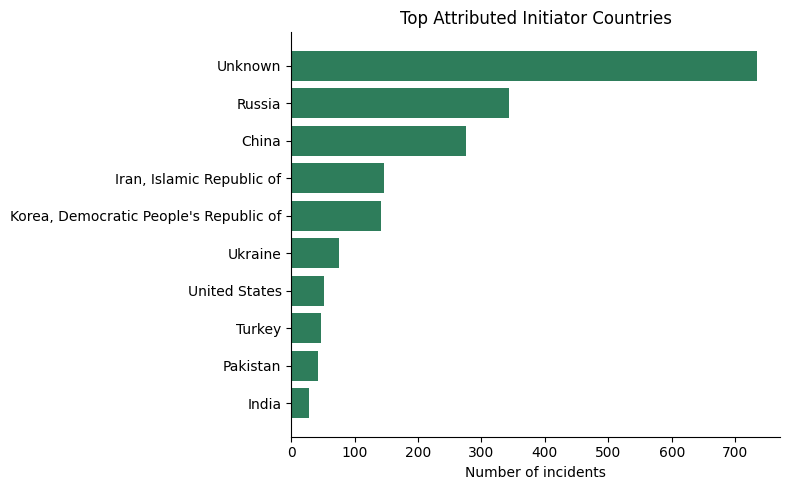

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
top_init = df_clean[~df_clean['initiator_cat_clean'].isin(['Not attributed','Unknown'])]
top_countries = top_init['initiator_country'].value_counts().head(10).sort_values()
ax.barh(top_countries.index, top_countries.values, color='#2e7d5b')
ax.set_title('Top Attributed Initiator Countries')
ax.set_xlabel('Number of incidents')
plt.tight_layout()
plt.show()

### 4.3 Initiator Category

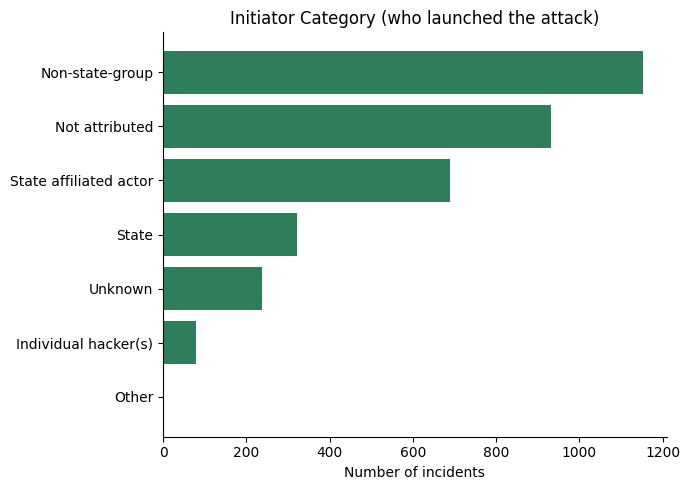

In [13]:
fig, ax = plt.subplots(figsize=(7,5))
cats = df_clean['initiator_cat_clean'].value_counts().head(8).sort_values()
ax.barh(cats.index, cats.values, color='#2e7d5b')
ax.set_title('Initiator Category (who launched the attack)')
ax.set_xlabel('Number of incidents')
plt.tight_layout()
plt.show()

### 4.4 Receiver Category

/var/folders/md/pk7z7t4n2099wq6jh6px_z4h0000gn/T/ipykernel_28902/3606753996.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


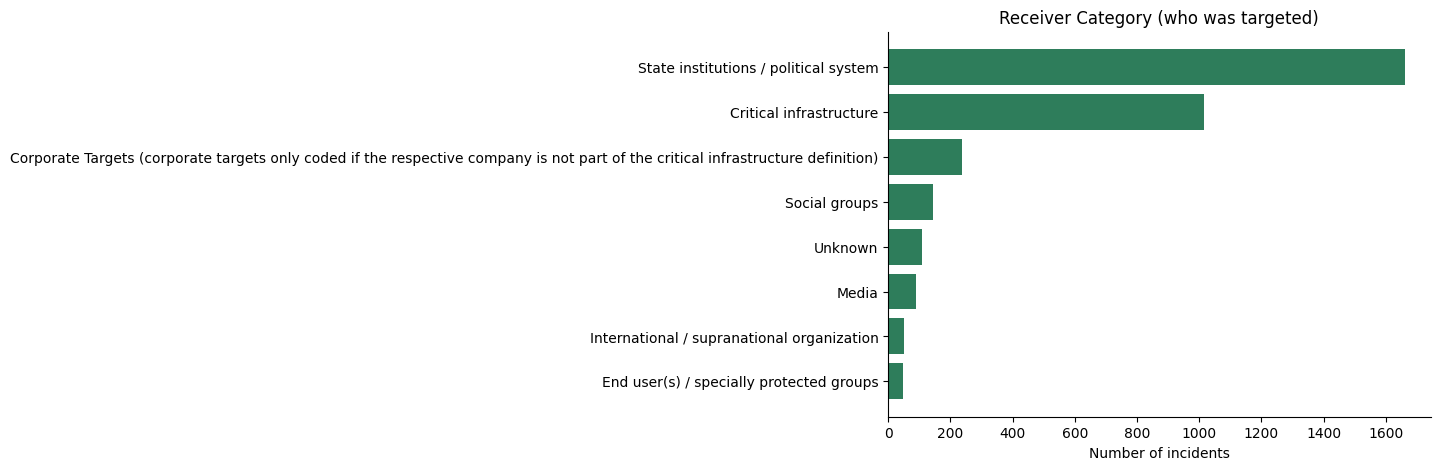

In [14]:
fig, ax = plt.subplots(figsize=(7,5))
rcats = df_clean['receiver_category'].str.split(';').str[0].value_counts().head(8).sort_values()
ax.barh(rcats.index, rcats.values, color='#2e7d5b')
ax.set_title('Receiver Category (who was targeted)')
ax.set_xlabel('Number of incidents')
plt.tight_layout()
plt.show()

### 4.5 Top Attack Corridors (Initiator -> Receiver, dyadic data)

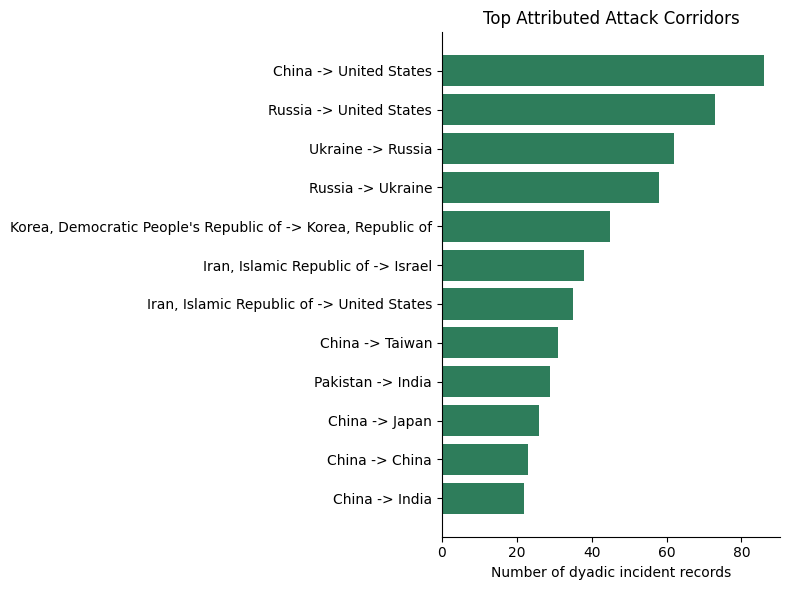

In [15]:
mask = (~dyad['initiator_country'].isin(DISGUISED_NULLS)) & (~dyad['receiver_country'].isin(DISGUISED_NULLS)) \
       & dyad['initiator_country'].notna() & dyad['receiver_country'].notna()
pairs = dyad[mask].groupby(['initiator_country','receiver_country']).size().sort_values(ascending=False).head(12)
labels = [f"{a} -> {b}" for a,b in pairs.index]

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(labels[::-1], pairs.values[::-1], color='#2e7d5b')
ax.set_title('Top Attributed Attack Corridors')
ax.set_xlabel('Number of dyadic incident records')
plt.tight_layout()
plt.show()

### 4.6 Weighted Intensity by Initiator Category

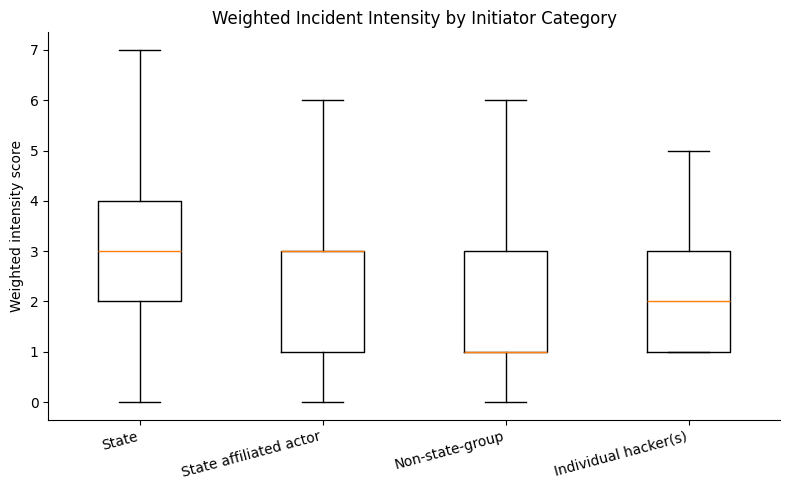

In [16]:
top_cats = ['State','State affiliated actor','Non-state-group','Individual hacker(s)']
data_box = [df_clean.loc[df_clean['initiator_cat_clean']==c, 'weighted_intensity'].dropna() for c in top_cats]

fig, ax = plt.subplots(figsize=(8,5))
ax.boxplot(data_box, tick_labels=top_cats, showfliers=False)
ax.set_title('Weighted Incident Intensity by Initiator Category')
ax.set_ylabel('Weighted intensity score')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 4.7 MITRE ATT&CK Initial Access (where recorded)

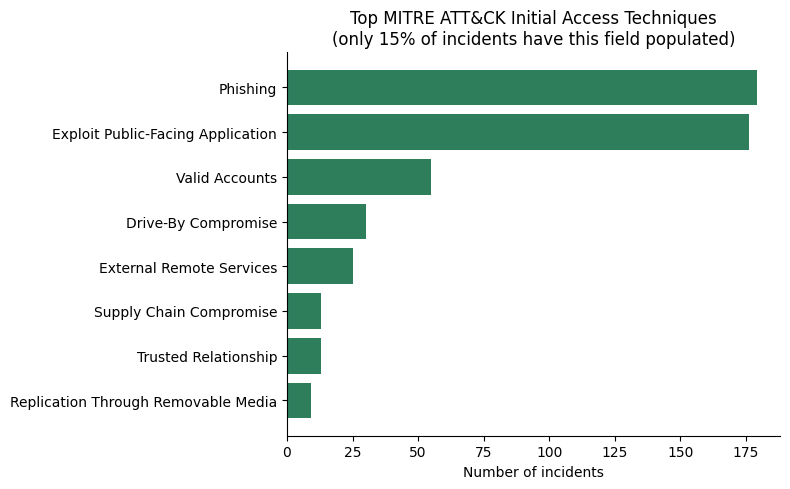

In [17]:
mitre = df_clean['mitre_initial_access'].value_counts()
mitre = mitre[~mitre.index.isin(DISGUISED_NULLS)].head(8).sort_values()

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(mitre.index, mitre.values, color='#2e7d5b')
ax.set_title('Top MITRE ATT&CK Initial Access Techniques\n(only 15% of incidents have this field populated)')
ax.set_xlabel('Number of incidents')
plt.tight_layout()
plt.show()

### 4.8 Attribution Difficulty Over Time

**Caveat before reading this chart:** attribution is often only established months or years after an
incident. Recent years look "less attributed" partly because the investigative/attribution process for
those incidents simply hasn't finished yet — treat the last 1-2 years of this trend with caution.

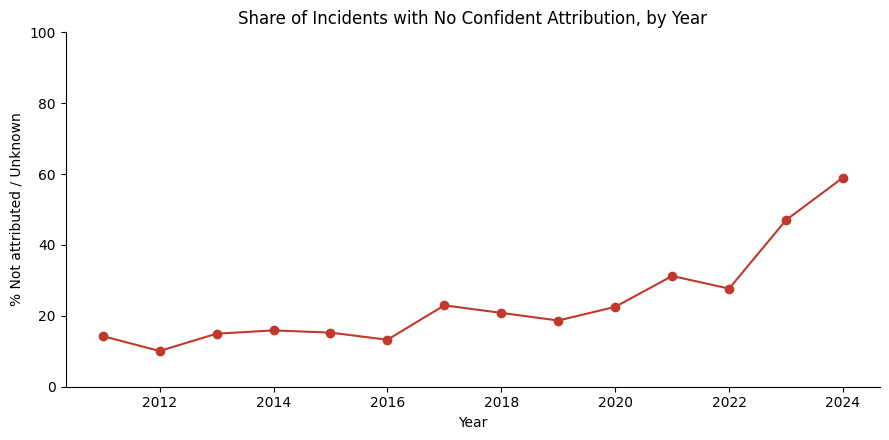

In [18]:
yearly_attr = df_clean[(df_clean['year']>=2011)&(df_clean['year']<=2024)].groupby('year')['not_attributed'].mean()*100

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(yearly_attr.index, yearly_attr.values, marker='o', color='#c0392b')
ax.set_title('Share of Incidents with No Confident Attribution, by Year')
ax.set_ylabel('% Not attributed / Unknown'); ax.set_xlabel('Year')
ax.set_ylim(0,100)
plt.tight_layout()
plt.show()

### 4.9 Zero-Day Usage Over Time

**Caveat:** only 98 incidents total involve a confirmed zero-day (2.9% of the dataset) — treat year-to-year movement as small-sample noise, not a real trend.

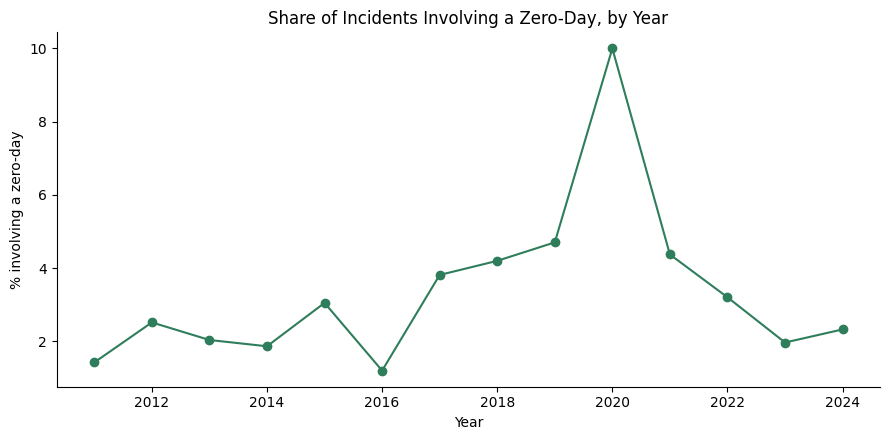

In [19]:
zd = df_clean[df_clean['zero_days'].isin(['Yes','No'])].copy()
zd_yearly = zd[(zd['year']>=2011)&(zd['year']<=2024)].groupby('year')['zero_days'].apply(lambda s: (s=='Yes').mean()*100)

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(zd_yearly.index, zd_yearly.values, marker='o', color='#2e7d5b')
ax.set_title('Share of Incidents Involving a Zero-Day, by Year')
ax.set_ylabel('% involving a zero-day'); ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

### 4.10 Incident Type Volume Over Time (dyadic records)

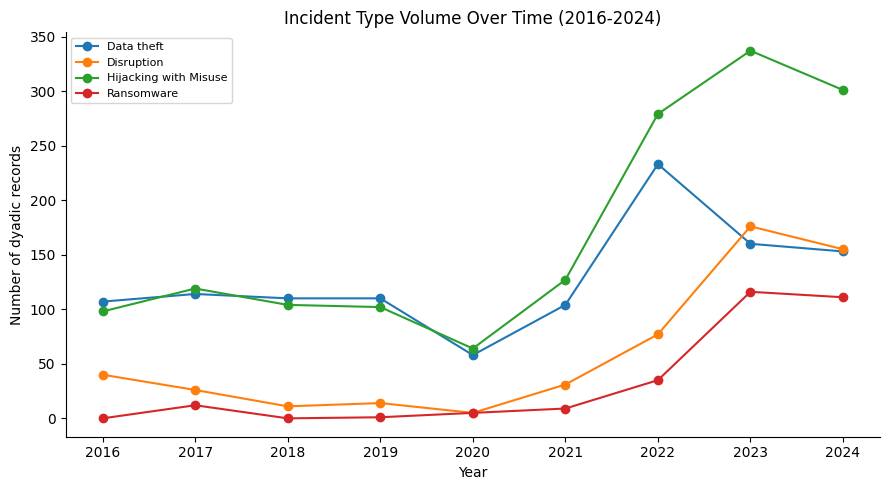

In [20]:
type_cols = ['Data theft','Disruption','Hijacking with Misuse','Ransomware']
dy = dyad[(dyad['year']>=2016)&(dyad['year']<=2024)]
trend = dy.groupby('year')[type_cols].sum()

fig, ax = plt.subplots(figsize=(9,5))
for col in type_cols:
    ax.plot(trend.index, trend[col], marker='o', label=col)
ax.set_title('Incident Type Volume Over Time (2016-2024)')
ax.set_ylabel('Number of dyadic records'); ax.set_xlabel('Year')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 4.11 Cyber Conflict Issue by Initiator Category

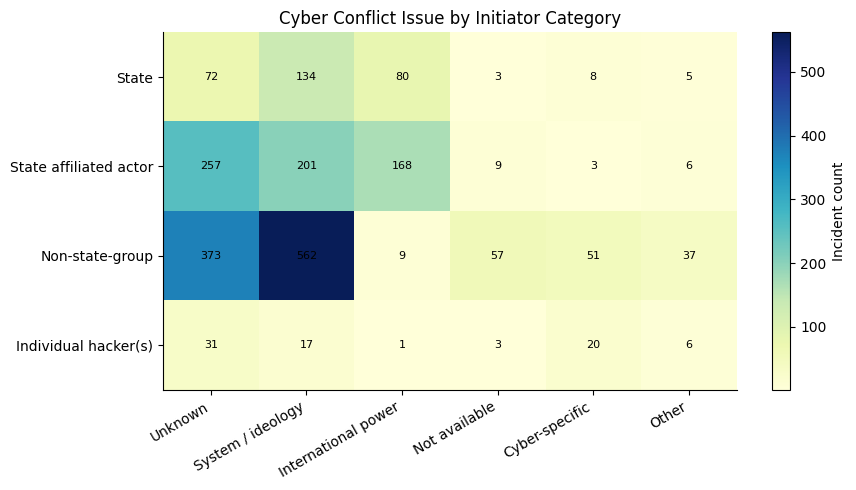

In [21]:
top_issues = df_clean['issue_clean'].value_counts().head(6).index.tolist()
top_cats2 = ['State','State affiliated actor','Non-state-group','Individual hacker(s)']
heat = pd.DataFrame(index=top_cats2, columns=top_issues, dtype=float)
for c in top_cats2:
    for iss in top_issues:
        heat.loc[c, iss] = ((df_clean['initiator_cat_clean']==c) & (df_clean['issue_clean']==iss)).sum()

fig, ax = plt.subplots(figsize=(9,5))
im = ax.imshow(heat.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(top_issues))); ax.set_xticklabels(top_issues, rotation=30, ha='right')
ax.set_yticks(range(len(top_cats2))); ax.set_yticklabels(top_cats2)
for i in range(len(top_cats2)):
    for j in range(len(top_issues)):
        ax.text(j, i, int(heat.values[i,j]), ha='center', va='center', fontsize=8)
ax.set_title('Cyber Conflict Issue by Initiator Category')
plt.colorbar(im, label='Incident count')
plt.tight_layout()
plt.show()

### 4.12 Industry/Receiver Category x Attack Category Heatmap

/var/folders/md/pk7z7t4n2099wq6jh6px_z4h0000gn/T/ipykernel_28902/3258113677.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


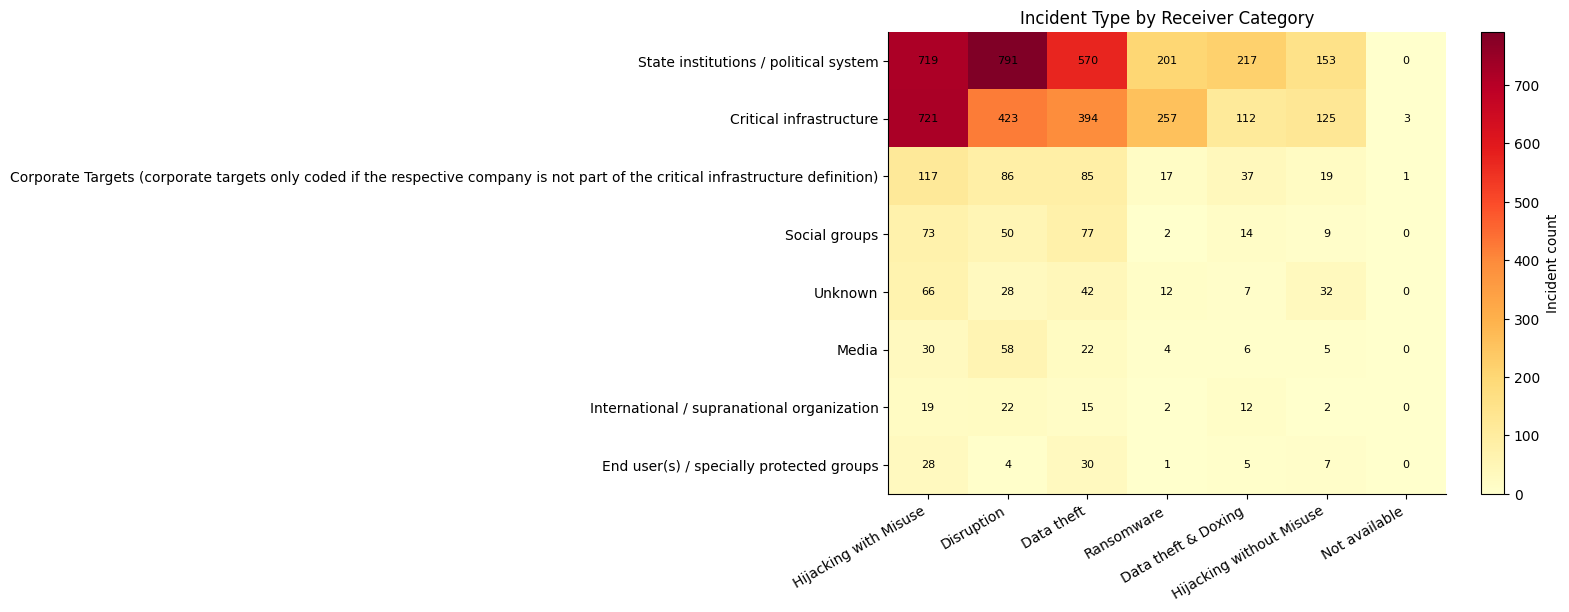

In [22]:
top_ind = df_clean['receiver_category'].str.split(';').str[0].value_counts().head(8).index
type_flag_cols = ['incident_type']
# Build per-category flags from incident_type (deduped) for the top receiver categories
categories = df_clean['incident_type'].str.split(';').explode().str.strip().value_counts().head(7).index.tolist()

heat2 = pd.DataFrame(index=top_ind, columns=categories, dtype=float)
rc_first = df_clean['receiver_category'].str.split(';').str[0]
for r in top_ind:
    mask_r = rc_first == r
    types_r = df_clean.loc[mask_r, 'incident_type'].str.split(';').explode().str.strip()
    counts = types_r.value_counts()
    for cat in categories:
        heat2.loc[r, cat] = counts.get(cat, 0)

fig, ax = plt.subplots(figsize=(9,6))
im = ax.imshow(heat2.values.astype(float), cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(categories))); ax.set_xticklabels(categories, rotation=30, ha='right')
ax.set_yticks(range(len(top_ind))); ax.set_yticklabels(top_ind)
for i in range(len(top_ind)):
    for j in range(len(categories)):
        ax.text(j, i, int(heat2.values[i,j]), ha='center', va='center', fontsize=8)
ax.set_title('Incident Type by Receiver Category')
plt.colorbar(im, label='Incident count')
plt.tight_layout()
plt.show()

## 5. Key Findings Summary

- **Volume trend:** incidents surge from 2021 onward (71 in 2020 -> 723 in 2023), driven by the Russia-Ukraine war and expanded EuRepoC tracking — the opposite pattern from breach-notification datasets like VCDB, which taper off after 2018.
- **Attribution:** ~34% of incidents are never confidently attributed; among attributed ones, non-state groups outnumber states, but China and Russia dominate state-linked activity.
- **Geopolitics is visible in the data:** the top attack corridors (China->US, Russia->US, Ukraine<->Russia, North Korea->South Korea, Iran->Israel) map directly onto known geopolitical rivalries.
- **Data completeness varies sharply by field:** core fields (dates, receiver, incident type) are reliable; attribution depth, MITRE mapping, and economic impact are majority placeholder text and should be used cautiously, with the gap itself reported as a finding.
- **Two trends need explicit caveats before use:** the attribution-difficulty and zero-day trends both plausibly reflect data-recency/sample-size artifacts rather than real-world change.

See the companion Data Quality Report for the full cleaning methodology and rationale.